In [2]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
x=np.linspace(0, 5, 6)
print(x, x.shape)
print(x[np.newaxis,:], x[np.newaxis,:].shape)
print(x[:,np.newaxis], x[:,np.newaxis].shape)

[0. 1. 2. 3. 4. 5.] (6,)
[[0. 1. 2. 3. 4. 5.]] (1, 6)
[[0.]
 [1.]
 [2.]
 [3.]
 [4.]
 [5.]] (6, 1)


In [4]:
x=np.load("formationchannels.npy")

In [5]:
print(x)

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]]


In [6]:
print(x, x.shape)
print(x[np.newaxis,:], x[np.newaxis,:].shape)
print(x[:,np.newaxis], x[:,np.newaxis].shape)

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]] (2950, 1)
[[[17.12172682]
  [ 5.94121793]
  [ 6.35914124]
  ...
  [34.34170191]
  [30.27018478]
  [25.93264098]]] (1, 2950, 1)
[[[17.12172682]]

 [[ 5.94121793]]

 [[ 6.35914124]]

 ...

 [[34.34170191]]

 [[30.27018478]]

 [[25.93264098]]] (2950, 1, 1)


(array([  1.,   0.,   1.,   1.,   1.,   0.,   2.,   3.,   2.,   1.,   4.,
          1.,   3.,   7.,   6.,  11.,   4.,  11.,   9.,  15.,  13.,   9.,
         11.,  19.,  19.,  11.,  16.,  17.,  19.,  12.,  14.,  14.,   9.,
         15.,  13.,   4.,  12.,  10.,   3.,   5.,   8.,  14.,  23.,  40.,
         72., 117., 145., 129., 104.,  51.,  38.,  26.,  48.,  44.,  47.,
         47.,  51.,  73.,  59.,  80.,  69.,  75.,  78.,  85.,  82.,  88.,
         86.,  84.,  80.,  71.,  87.,  58.,  57.,  65.,  49.,  48.,  32.,
         33.,  32.,  26.,  34.,  17.,  15.,  14.,  11.,  12.,   2.,   6.,
          0.,   1.,   2.,   2.,   2.,   0.,   1.,   0.,   0.,   1.,   0.,
          1.]),
 array([-4.965425  , -4.42875831, -3.89209161, -3.35542492, -2.81875822,
        -2.28209152, -1.74542483, -1.20875813, -0.67209144, -0.13542474,
         0.40124195,  0.93790865,  1.47457534,  2.01124204,  2.54790873,
         3.08457543,  3.62124212,  4.15790882,  4.69457551,  5.23124221,
         5.7679089 ,  6.30

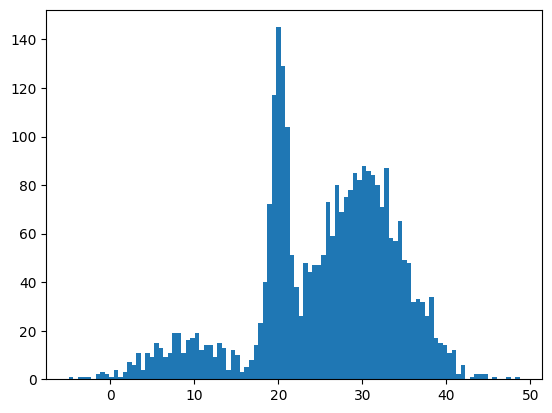

In [7]:
plt.hist(x, bins=100)

In [8]:
N=[1,2,3,4,5,6,7,8,9,10]
AIC_array=np.array([])
for i in range(len(N)):
    gm=sklearn.mixture.GaussianMixture(N[i])
    z=gm.fit(X=x, y=None)
    print(z.means_)
    AIC=gm.aic(x)
    AIC_array=np.append(AIC_array,AIC)


[[25.52008475]]
[[19.84784652]
 [30.02705269]]
[[30.12777783]
 [20.05283694]
 [ 9.09033281]]
[[34.27727863]
 [ 9.22691207]
 [20.09352074]
 [28.11432519]]
[[20.13277741]
 [31.24804341]
 [ 9.21388659]
 [36.09218836]
 [26.26418423]]
[[36.05665547]
 [26.22062604]
 [20.10934464]
 [11.26576125]
 [31.20853802]
 [ 5.38257996]]
[[20.100433  ]
 [32.98499731]
 [11.35705197]
 [29.3143018 ]
 [25.34904798]
 [37.23639819]
 [ 5.39167947]]
[[32.96849928]
 [25.39237541]
 [ 5.24328517]
 [37.14462864]
 [19.41166028]
 [11.22579893]
 [20.49456066]
 [29.36206408]]
[[20.07145078]
 [30.32709029]
 [ 5.40928036]
 [36.03479013]
 [24.22246408]
 [11.43043949]
 [27.36065034]
 [39.04914673]
 [33.05120525]]
[[26.74066937]
 [ 8.19080583]
 [34.99723607]
 [20.05046782]
 [32.08084278]
 [38.26183678]
 [ 3.40815177]
 [23.90215661]
 [13.28125187]
 [29.46636511]]


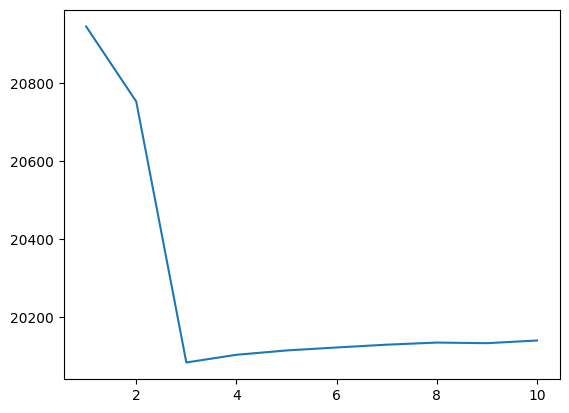

In [9]:
plt.plot(N,AIC_array)

In [10]:
bestfit=N[np.argmin(AIC_array)]

In [13]:
gm_fit=sklearn.mixture.GaussianMixture(bestfit)
z_fit=gm_fit.fit(X=x, y=None)
print(z_fit.get_params())
mu=z_fit.means_
weights=z_fit.weights_
sigma=np.sqrt(z_fit.covariances_)
print(gm_fit)
#print(z_fit.covars_)
print(weights)

{'covariance_type': 'full', 'init_params': 'kmeans', 'max_iter': 100, 'means_init': None, 'n_components': 3, 'n_init': 1, 'precisions_init': None, 'random_state': None, 'reg_covar': 1e-06, 'tol': 0.001, 'verbose': 0, 'verbose_interval': 10, 'warm_start': False, 'weights_init': None}
GaussianMixture(n_components=3)
[0.66965717 0.11625557 0.21408726]


(array([0.00063165, 0.        , 0.00063165, 0.00063165, 0.00063165,
        0.        , 0.00126329, 0.00189494, 0.00126329, 0.00063165,
        0.00252658, 0.00063165, 0.00189494, 0.00442152, 0.00378987,
        0.0069481 , 0.00252658, 0.0069481 , 0.00568481, 0.00947468,
        0.00821139, 0.00568481, 0.0069481 , 0.01200126, 0.01200126,
        0.0069481 , 0.01010633, 0.01073797, 0.01200126, 0.00757974,
        0.00884304, 0.00884304, 0.00568481, 0.00947468, 0.00821139,
        0.00252658, 0.00757974, 0.00631645, 0.00189494, 0.00315823,
        0.00505316, 0.00884304, 0.01452784, 0.02526582, 0.04547847,
        0.07390251, 0.09158858, 0.08148226, 0.06569112, 0.03221392,
        0.02400253, 0.01642278, 0.03031898, 0.0277924 , 0.02968733,
        0.02968733, 0.03221392, 0.04611011, 0.03726708, 0.05053163,
        0.04358353, 0.04737341, 0.04926834, 0.05368986, 0.05179492,
        0.0555848 , 0.0543215 , 0.05305821, 0.05053163, 0.04484682,
        0.05495315, 0.03663543, 0.03600379, 0.04

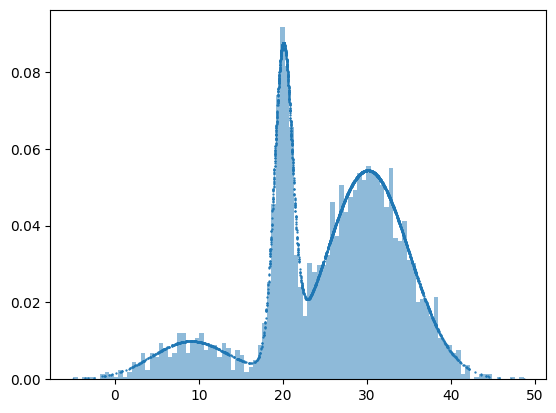

In [18]:
data=np.array([0]*len(x))
aa=np.array([])
for i in range(len(mu)):
    dist=norm(mu[i],sigma[i])
    #print(mu[i],sigma[i])
    
    y=dist.pdf(x)*weights[i]
    #print(y)
    aaa=np.append(aa,y)
    data=data+aaa
    
    #print(data)
    
plt.scatter(x,data,s=0.4)
plt.hist(x, bins=100, alpha=0.5, density='True')